# Model Analysis (Tasks 2-4)

In [319]:
import sys
from pathlib import Path

import json
import joblib
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import loguniform, uniform

import mrmr
from mrmr import mrmr_regression
from sklearn.linear_model import LinearRegression, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib_venn import venn2
import seaborn as sns

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))
from functions import bootstrap_metrics, stability_selection

seed=42

In [5]:
# loading & unpacking sets used
data = joblib.load(f'{project_root}/data/processed_data.pkl')

X_train = data['X_train']
y_train = data['y_train']
z_train = data['z_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']
feature_sets = data['feature_sets']

# Task 2: Baseline Models
## 2.1  OLS LinearRegression across feature sets

In [8]:
OLS_metrics = {}
OLS_raw = {}

for f_set, (X_t, X_v) in feature_sets.items():
    model = LinearRegression()
    model.fit(X_t, y_train)
    
    y_hat = model.predict(X_v)
    
    OLS_metrics[f_set], OLS_raw[f_set] = bootstrap_metrics(y_val, y_hat)

In [9]:
display(pd.DataFrame(OLS_metrics).T)

,RMSE,MAE,R2,Pearson_r
Metadata,"12.873 ± 1.084, [10.977 - 15.140]","10.347 ± 0.789, [8.902 - 11.914]","0.223 ± 0.075, [0.063 - 0.357]","0.483 ± 0.078, [0.319 - 0.625]"
CpG,"4.746 ± 0.567, [3.701 - 5.918]","3.574 ± 0.330, [2.950 - 4.269]","0.892 ± 0.029, [0.823 - 0.936]","0.950 ± 0.014, [0.917 - 0.971]"
Combined,"4.724 ± 0.560, [3.682 - 5.881]","3.560 ± 0.327, [2.940 - 4.245]","0.893 ± 0.029, [0.826 - 0.937]","0.950 ± 0.014, [0.918 - 0.971]"


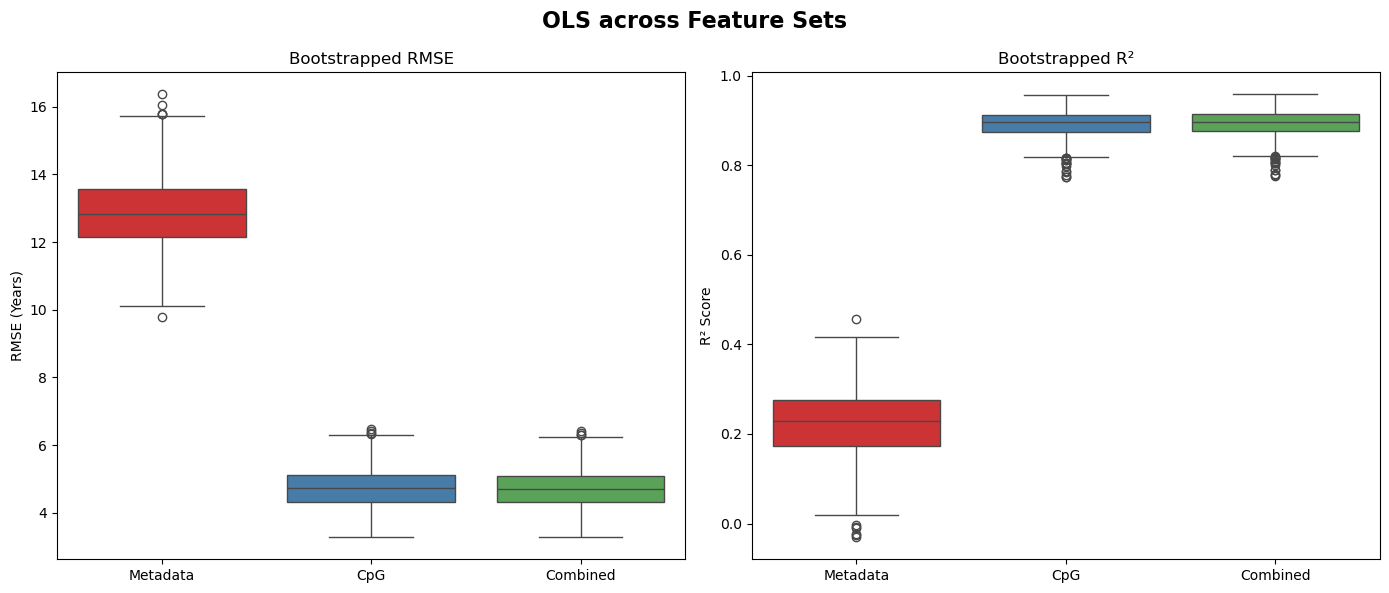

In [12]:
# boxplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle('OLS across Feature Sets', 
             fontsize=16, fontweight='bold')

# RMSE
OLS_rmse = pd.DataFrame({k: v['RMSE'] for k, v in OLS_raw.items()})
sns.boxplot(data=OLS_rmse, ax=ax1, palette="Set1")
ax1.set_title('Bootstrapped RMSE')
ax1.set_ylabel('RMSE (Years)')

# R2
OLS_r2 = pd.DataFrame({k: v['R2'] for k, v in OLS_raw.items()})
sns.boxplot(data=OLS_r2, ax=ax2, palette="Set1")
ax2.set_title('Bootstrapped R²')
ax2.set_ylabel('R² Score')

plt.tight_layout()

plt.savefig(f'{project_root}/figures/OLS_FS_bootstrap_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

## 2.2  Three regression models at default hyperparameters

In [15]:
models = {
    "ElasticNet": ElasticNet(random_state=seed),
    "SVR": SVR(),
    "BayesianRidge": BayesianRidge()
}

models_metrics = {}
models_raw = {}

for name, model in models.items():
    model.fit(X_train, y_train) # fitting on CpG only
    
    y_hat = model.predict(X_val)
    
    models_metrics[name], models_raw[name] = bootstrap_metrics(y_val, y_hat)

In [16]:
# baselines
reg_baselines_df = pd.DataFrame(models_metrics).T
display(reg_baselines_df)

,RMSE,MAE,R2,Pearson_r
ElasticNet,"4.512 ± 0.408, [3.742 - 5.305]","3.478 ± 0.295, [2.912 - 4.083]","0.903 ± 0.022, [0.853 - 0.938]","0.953 ± 0.012, [0.926 - 0.971]"
SVR,"9.301 ± 0.996, [7.391 - 11.267]","6.822 ± 0.690, [5.508 - 8.249]","0.596 ± 0.044, [0.505 - 0.675]","0.848 ± 0.027, [0.791 - 0.896]"
BayesianRidge,"3.880 ± 0.438, [3.116 - 4.754]","2.909 ± 0.271, [2.410 - 3.463]","0.928 ± 0.019, [0.885 - 0.958]","0.965 ± 0.010, [0.942 - 0.980]"


In [91]:
round(np.mean(models_rmse, axis=0), 3)

OLS              4.746
ElasticNet       4.512
SVR              9.301
BayesianRidge    3.880
dtype: float64

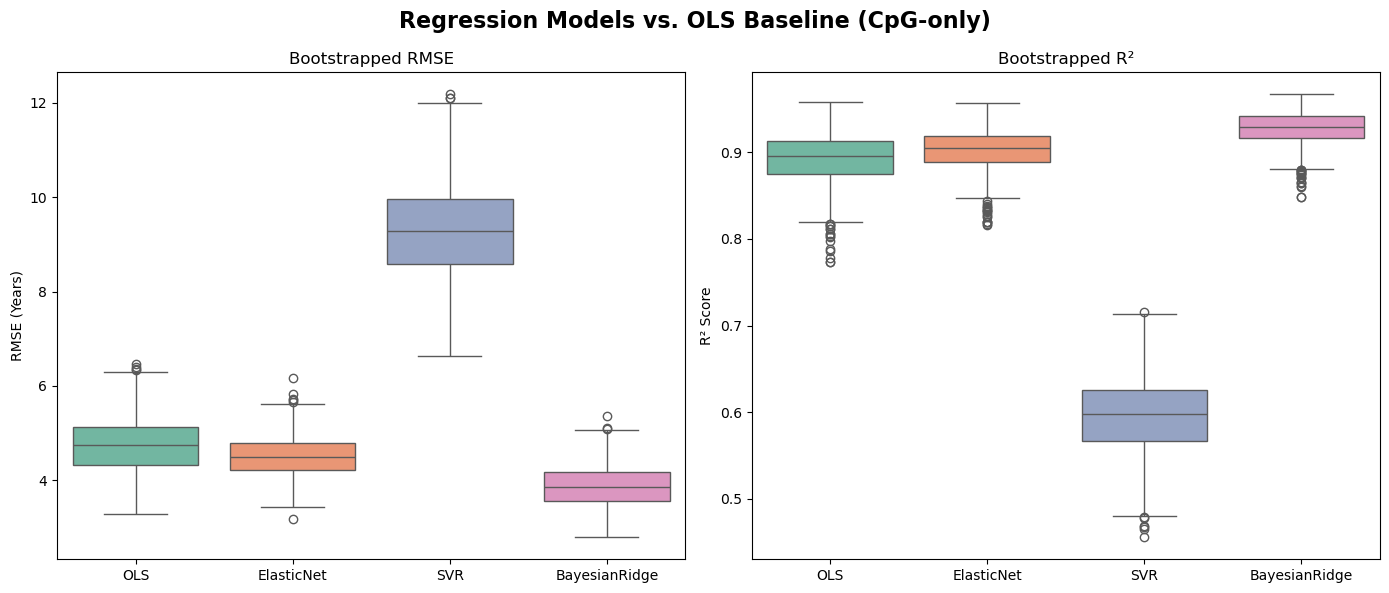

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle('Regression Models vs. OLS Baseline (CpG-only)', 
             fontsize=16, fontweight='bold')

# RMSE
models_rmse = pd.concat([
    OLS_rmse[['CpG']].rename(columns={'CpG': 'OLS'}), 
    pd.DataFrame({k: v['RMSE'] for k, v in models_raw.items()})
], axis=1)
sns.boxplot(data=models_rmse, ax=ax1, palette="Set2")
ax1.set_title('Bootstrapped RMSE')
ax1.set_ylabel('RMSE (Years)')

# R2
models_r2 = pd.concat([
    OLS_r2[['CpG']].rename(columns={'CpG': 'OLS'}), 
    pd.DataFrame({k: v['R2'] for k, v in models_raw.items()})
], axis=1)
sns.boxplot(data=models_r2, ax=ax2, palette="Set2")
ax2.set_title('Bootstrapped R²')
ax2.set_ylabel('R² Score')

plt.tight_layout()
plt.savefig(f'{project_root}/figures/RegModels_bootstrap_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# Task 3: Feature Selection (FS)
## 3.1  Stability Selection

In [24]:
stable_feats, stable_counts = stability_selection(X_train.rank(), y_train.rank())
print(f'Selected Features: {len(stable_feats)}')

Selected Features: 186


## 3.2   Minimum Redundancy Maximum Relevance  (mRMR)

In [35]:
mrmr_rank = mrmr_regression(X=X_train, y=y_train, K=200, return_scores=False, show_progress=False)

BayRidge = BayesianRidge()

ks = list(range(10, 201, 5))
rmses = []

for k in ks:
    features = mrmr_rank[:k]
    BayRidge.fit(X_train[features], y_train)
    
    y_hat = BayRidge.predict(X_val[features])
    
    rmses.append(np.sqrt(mean_squared_error(y_val, y_hat)))

optimal_k = ks[np.argmin(rmses)]
mrmr_feats = mrmr_rank[:optimal_k]

print(f"Optimal K: {optimal_k}")

Optimal K: 155


In [323]:
with open(f'{project_root}/data/mrmr_feats_age.json', "w") as f:
    json.dump(mrmr_feats, f)

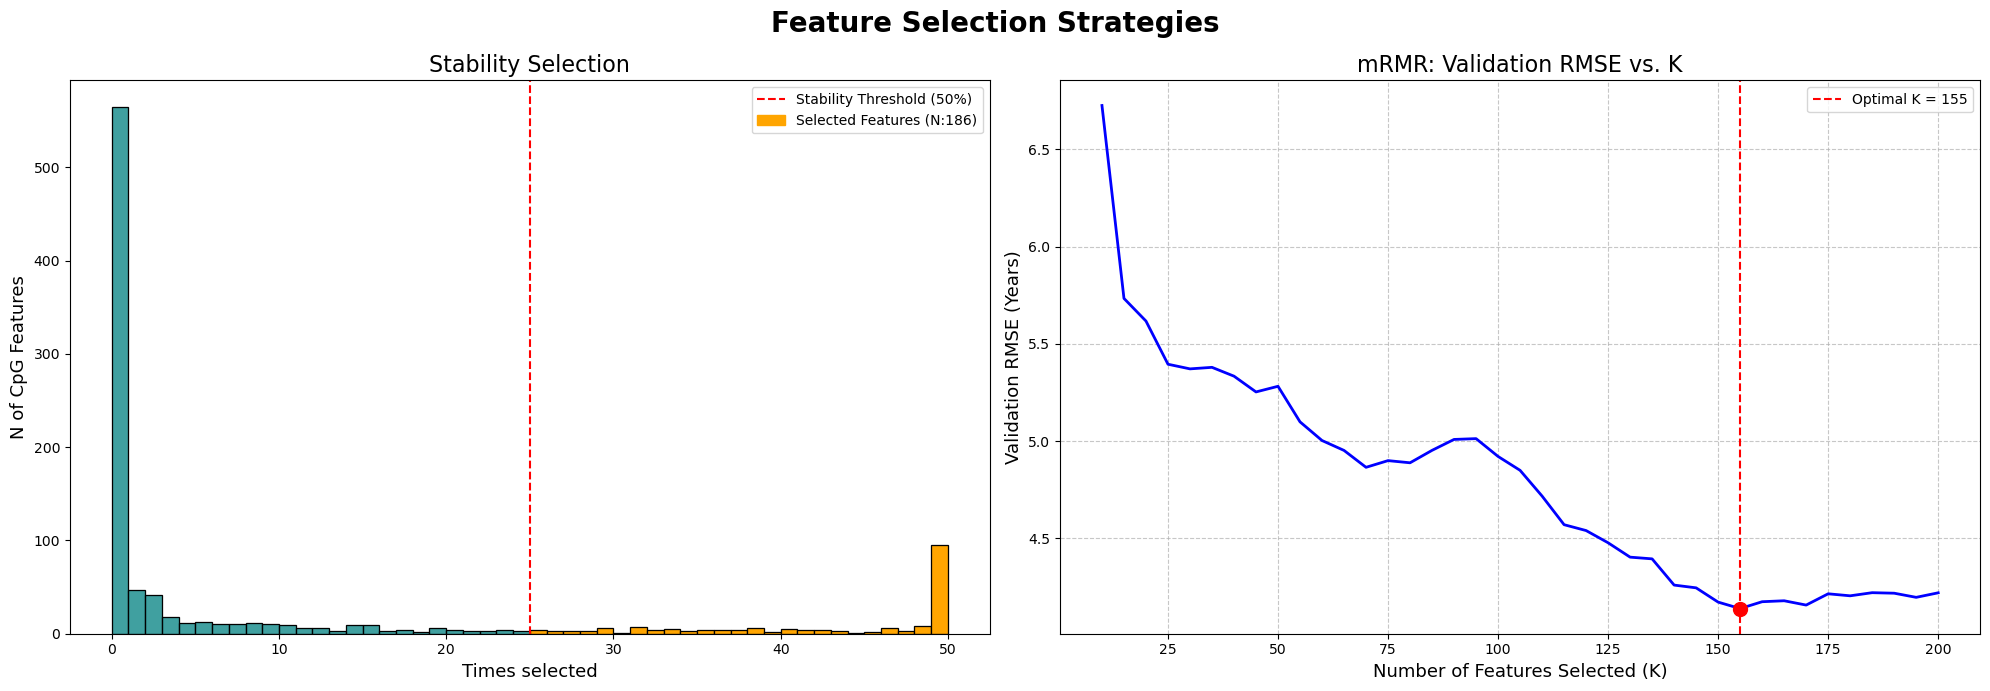

In [102]:
# FS plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Stability Selection
sns.histplot(stable_counts, bins=50, kde=False, color='teal', ax=ax1)

for patch in ax1.patches:
    if patch.get_x() >= 25:
        patch.set_facecolor('orange')

selected_patch = mpatches.Patch(color='orange', label=f'Selected Features (N:{len(stable_feats)})')
ax1.axvline(25, color='red', linestyle='--', label='Stability Threshold (50%)')

ax1.set_title('Stability Selection', fontsize=16)
ax1.set_xlabel('Times selected', fontsize=13)
ax1.set_ylabel('N of CpG Features', fontsize=13)

handles1, labels1 = ax1.get_legend_handles_labels()
handles1.append(selected_patch)
ax1.legend(handles=handles1)


# mRMR 
sns.lineplot(x=ks, y=rmses, color='b', linewidth=2, ax=ax2)

min_rmse = min(rmses)
ax2.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K = {optimal_k}')
ax2.scatter(optimal_k, min_rmse, color='red', s=100, zorder=5)

ax2.set_title('mRMR: Validation RMSE vs. K', fontsize=16)
ax2.set_xlabel('Number of Features Selected (K)', fontsize=13)
ax2.set_ylabel('Validation RMSE (Years)', fontsize=13)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

fig.suptitle('Feature Selection Strategies', 
             fontsize=20, fontweight='bold')

plt.tight_layout()

plt.tight_layout()

plt.savefig(f'{project_root}/figures/FS_Combined.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
top_10, scores, _ = mrmr_regression(X=X_train, y=y_train, K=10, return_scores=True, show_progress=False)

In [41]:
scores[top_10]

cg16867657    813.478477
cg06639320    482.477224
cg10501210    438.372199
cg22454769    486.320790
cg24724428    410.383818
cg21572722    379.886424
cg22796704    302.757932
cg24079702    367.679979
cg01974375    303.058878
cg06784991    292.791897
dtype: float64

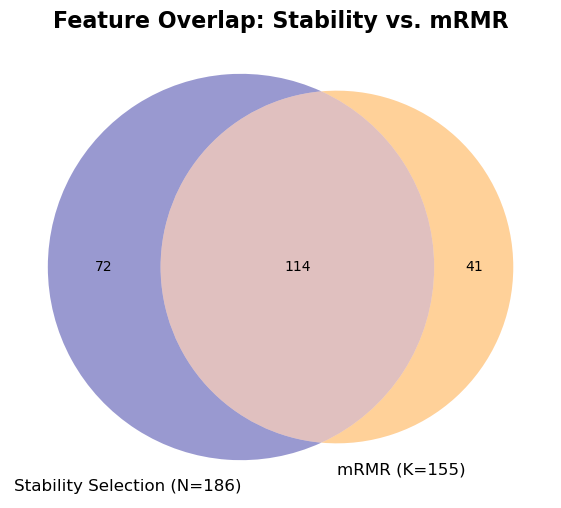

In [43]:
# venn overlap plot
plt.figure(figsize=(8, 6))

venn2([set(stable_feats), set(mrmr_feats)], 
      set_labels=(f'Stability Selection (N={len(stable_feats)})', f'mRMR (K={optimal_k})'),
      set_colors=('darkblue', 'darkorange'))

plt.title('Feature Overlap: Stability vs. mRMR', fontsize=16, fontweight='bold')
plt.savefig(f'{project_root}/figures/FS_venn.png', dpi=300, bbox_inches='tight')
plt.show()

## 3.3  Method comparison and selection

In [48]:
# FS methods validated with Bayesian Ridge

# Stability Selection
BayRidge.fit(X_train[stable_feats], y_train)
y_hat_ss = BayRidge.predict(X_val[stable_feats])
stable_metrics, _ = bootstrap_metrics(y_val, y_hat_ss)

# mRMR
BayRidge.fit(X_train[mrmr_feats], y_train)
y_hat_mrmr = BayRidge.predict(X_val[mrmr_feats])
mrmr_metrics, _ = bootstrap_metrics(y_val, y_hat_mrmr)

FS_table = pd.DataFrame({
    "Method": ["Stability Selection", "mRMR"],
    "Features Selected": [len(stable_feats), optimal_k],
    "Validation RMSE": [stable_metrics['RMSE'], mrmr_metrics['RMSE']],
    "Validation R²": [stable_metrics['R2'], mrmr_metrics['R2']]
})

display(FS_table)

,Method,Features Selected,Validation RMSE,Validation R²
0,Stability Selection,186,"4.828 ± 0.433, [4.027 - 5.694]","0.889 ± 0.025, [0.827 - 0.929]"
1,mRMR,155,"4.124 ± 0.379, [3.415 - 4.856]","0.918 ± 0.020, [0.874 - 0.950]"


# Task 4: Hyperparameter Tuning and Final Evaluation

In [52]:
# Final dev set: train + val combined, CpG only, 155 mRMR selected features
X_dev = pd.concat([X_train[mrmr_feats], X_val[mrmr_feats]], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

print(f'Development Set Shape: {X_dev.shape}')

Development Set Shape: (456, 155)


In [54]:
search_space = {
    "ElasticNet": {
        'alpha': loguniform(0.001, 10),
        'l1_ratio': uniform(loc=0.1, scale=0.9) # 0.1 to 1.0
    },
    "SVR": {
        'C': loguniform(0.1, 500),
        'epsilon': [0.01, 0.1, 0.5, 1.0],
        'kernel': ['rbf', 'linear']
    },
    "BayesianRidge": {
        'alpha_1': loguniform(1e-7, 1e-3),
        'alpha_2': loguniform(1e-7, 1e-3),
        'lambda_1': loguniform(1e-7, 1e-3),
        'lambda_2': loguniform(1e-7, 1e-3)
    }
}

models = {
    "ElasticNet": ElasticNet(random_state=42, max_iter=10000),
    "SVR": SVR(cache_size=2000),
    "BayesianRidge": BayesianRidge()
}

In [299]:
best_models = {}

for name, model in models.items():
    print(f"\n{'='*40}\nTuning {name}...\n{'='*40}")
    
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=search_space[name],
        n_iter=40,
        cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=3
    )
    
    search.fit(X_dev, y_dev)
    best_models[name] = search.best_estimator_
    
    best_rmse = -search.best_score_
    print(f"  Best CV RMSE: {best_rmse:.3f}")
    print(f"  Best Params: {search.best_params_}\n")


Tuning ElasticNet...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
  Best CV RMSE: 4.786
  Best Params: {'alpha': 0.23423849847112907, 'l1_ratio': 0.14180537144799796}


Tuning SVR...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
  Best CV RMSE: 5.161
  Best Params: {'C': 0.11916299962955149, 'epsilon': 0.1, 'kernel': 'linear'}


Tuning BayesianRidge...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
  Best CV RMSE: 4.811
  Best Params: {'alpha_1': 3.798214508453255e-07, 'alpha_2': 9.074256288983855e-06, 'lambda_1': 0.0008761971101023686, 'lambda_2': 9.294394155644988e-07}



## 4.2  Final model evaluation

In [669]:
# Test Set
X_test = X_test[mrmr_features]

In [671]:
best_models

{'ElasticNet': ElasticNet(alpha=0.23423849847112907, l1_ratio=0.14180537144799796,
            max_iter=10000, random_state=42),
 'SVR': SVR(C=0.11916299962955149, cache_size=2000, kernel='linear'),
 'BayesianRidge': BayesianRidge(alpha_1=3.798214508453255e-07, alpha_2=9.074256288983855e-06,
               lambda_1=0.0008761971101023686, lambda_2=9.294394155644988e-07)}

In [80]:
y_hats = {}
raw_metrics = {}
FS_tuned = []

for name, model in best_models.items():
    y_hat = model.predict(X_test)
    y_hats[name] = y_hat
    
    metrics, raw = bootstrap_metrics(y_test, y_hat)
    raw_metrics[name] = raw
    
    FS_tuned.append({
        "Model": name,
        "Stage": "FS+Tuned",
        "RMSE": metrics['RMSE'],
        "MAE": metrics['MAE'],
        "R2": metrics['R2'],
        "Pearson_r": metrics['Pearson_r']
    })

NameError: name 'best_models' is not defined

In [806]:
# FS + Tuned (evaluated on Test Set)
FS_tuned_df = pd.DataFrame(FS_tuned)
display(FS_tuned_df)

,Model,Stage,RMSE,MAE,R2,Pearson_r
0,ElasticNet,FS+Tuned,"5.164 ± 0.614, [4.067 - 6.426]","3.801 ± 0.343, [3.185 - 4.508]","0.863 ± 0.039, [0.773 - 0.928]","0.932 ± 0.020, [0.888 - 0.964]"
1,SVR,FS+Tuned,"5.549 ± 0.461, [4.658 - 6.460]","4.218 ± 0.350, [3.535 - 4.955]","0.843 ± 0.036, [0.762 - 0.907]","0.924 ± 0.017, [0.884 - 0.954]"
2,BayesianRidge,FS+Tuned,"5.257 ± 0.596, [4.176 - 6.491]","3.906 ± 0.345, [3.252 - 4.613]","0.858 ± 0.040, [0.767 - 0.924]","0.930 ± 0.020, [0.887 - 0.962]"


In [58]:
# FS-only (evaluated on Validation Set)
models

{'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
 'SVR': SVR(cache_size=2000),
 'BayesianRidge': BayesianRidge()}

In [68]:
FS_only = []

for name, model in models.items():
    
    model.fit(X_train[mrmr_feats], y_train)
    y_hat = model.predict(X_val[mrmr_feats])
    
    metrics, _ = bootstrap_metrics(y_val, y_hat)
        
    FS_only.append({
        "Model": name,
        "Stage": "FS-only",
        "RMSE": metrics['RMSE'],
        "MAE": metrics['MAE'],
        "R2": metrics['R2'],
        "Pearson_r": metrics['Pearson_r']
    })

In [70]:
# FS-only
FS_only_df = pd.DataFrame(FS_only)
display(FS_only_df)

,Model,Stage,RMSE,MAE,R2,Pearson_r
0,ElasticNet,FS-only,"4.702 ± 0.412, [3.939 - 5.536]","3.629 ± 0.313, [3.021 - 4.309]","0.894 ± 0.023, [0.841 - 0.932]","0.950 ± 0.012, [0.921 - 0.970]"
1,SVR,FS-only,"8.503 ± 1.074, [6.536 - 10.629]","6.069 ± 0.651, [4.865 - 7.399]","0.662 ± 0.050, [0.558 - 0.750]","0.859 ± 0.029, [0.799 - 0.909]"
2,BayesianRidge,FS-only,"4.124 ± 0.379, [3.415 - 4.856]","3.019 ± 0.291, [2.467 - 3.601]","0.918 ± 0.020, [0.874 - 0.950]","0.959 ± 0.010, [0.936 - 0.976]"


In [76]:
# Baselines
reg_baselines_df.insert(0, "Stage", "Baseline")
reg_baselines_df = reg_baselines_df.reset_index(names='Model')
display(reg_baselines_df)

,Model,Stage,RMSE,MAE,R2,Pearson_r
0,ElasticNet,Baseline,"4.512 ± 0.408, [3.742 - 5.305]","3.478 ± 0.295, [2.912 - 4.083]","0.903 ± 0.022, [0.853 - 0.938]","0.953 ± 0.012, [0.926 - 0.971]"
1,SVR,Baseline,"9.301 ± 0.996, [7.391 - 11.267]","6.822 ± 0.690, [5.508 - 8.249]","0.596 ± 0.044, [0.505 - 0.675]","0.848 ± 0.027, [0.791 - 0.896]"
2,BayesianRidge,Baseline,"3.880 ± 0.438, [3.116 - 4.754]","2.909 ± 0.271, [2.410 - 3.463]","0.928 ± 0.019, [0.885 - 0.958]","0.965 ± 0.010, [0.942 - 0.980]"


In [78]:
# Final Tables
model_names = list(reg_baselines_df['Model'])
dfs = [reg_baselines_df, FS_only_df, FS_tuned_df]

all_stages_df = pd.concat(dfs, ignore_index=True)
all_stages_dic = {model: group for model, group in all_stages_df.groupby("Model")}

NameError: name 'FS_tuned_df' is not defined

In [777]:
display(all_stages_dic['ElasticNet'])

,Model,Stage,RMSE,MAE,R2,Pearson_r
0,ElasticNet,Baseline,"4.512 ± 0.408, [3.742 - 5.305]","3.478 ± 0.295, [2.912 - 4.083]","0.903 ± 0.022, [0.853 - 0.938]","0.953 ± 0.012, [0.926 - 0.971]"
3,ElasticNet,FS-only,"5.118 ± 0.570, [4.061 - 6.301]","3.872 ± 0.327, [3.291 - 4.519]","0.866 ± 0.036, [0.783 - 0.923]","0.932 ± 0.020, [0.888 - 0.965]"
6,ElasticNet,FS+Tuned,"5.164 ± 0.614, [4.067 - 6.426]","3.801 ± 0.343, [3.185 - 4.508]","0.863 ± 0.039, [0.773 - 0.928]","0.932 ± 0.020, [0.888 - 0.964]"


In [779]:
display(all_stages_dic['SVR'])

,Model,Stage,RMSE,MAE,R2,Pearson_r
1,SVR,Baseline,"9.301 ± 0.996, [7.391 - 11.267]","6.822 ± 0.690, [5.508 - 8.249]","0.596 ± 0.044, [0.505 - 0.675]","0.848 ± 0.027, [0.791 - 0.896]"
4,SVR,FS-only,"8.027 ± 0.953, [6.326 - 9.963]","5.806 ± 0.540, [4.823 - 6.983]","0.678 ± 0.052, [0.568 - 0.770]","0.844 ± 0.031, [0.780 - 0.897]"
7,SVR,FS+Tuned,"5.549 ± 0.461, [4.658 - 6.460]","4.218 ± 0.350, [3.535 - 4.955]","0.843 ± 0.036, [0.762 - 0.907]","0.924 ± 0.017, [0.884 - 0.954]"


In [781]:
display(all_stages_dic['BayesianRidge'])

,Model,Stage,RMSE,MAE,R2,Pearson_r
2,BayesianRidge,Baseline,"3.880 ± 0.438, [3.116 - 4.754]","2.909 ± 0.271, [2.410 - 3.463]","0.928 ± 0.019, [0.885 - 0.958]","0.965 ± 0.010, [0.942 - 0.980]"
5,BayesianRidge,FS-only,"5.257 ± 0.596, [4.176 - 6.491]","3.906 ± 0.345, [3.252 - 4.613]","0.858 ± 0.040, [0.767 - 0.924]","0.930 ± 0.020, [0.887 - 0.962]"
8,BayesianRidge,FS+Tuned,"5.257 ± 0.596, [4.176 - 6.491]","3.906 ± 0.345, [3.252 - 4.613]","0.858 ± 0.040, [0.767 - 0.924]","0.930 ± 0.020, [0.887 - 0.962]"


In [120]:
# OLS for FS-only for comparison purposes
OLS = LinearRegression()

# 3. Fit on the development set (155 features)
OLS.fit(X_train[mrmr_feats], y_train)
y_hat = OLS.predict(X_val[mrmr_feats])

OLS_metrics, _ = bootstrap_metrics(y_val, y_hat)

display(OLS_metrics)

{'RMSE': '4.463 ± 0.365, [3.742 - 5.175]',
 'MAE': '3.559 ± 0.285, [3.017 - 4.098]',
 'R2': '0.905 ± 0.021, [0.860 - 0.939]',
 'Pearson_r': '0.955 ± 0.010, [0.933 - 0.973]'}

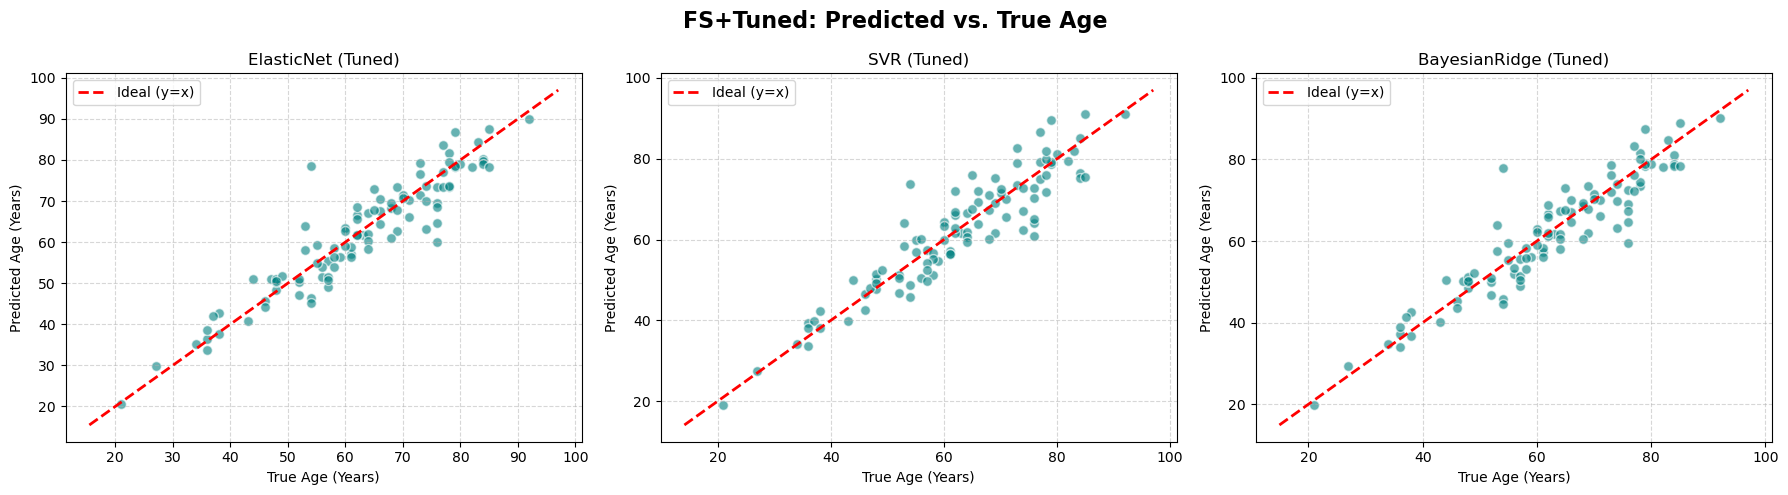

In [793]:
# scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('FS+Tuned: Predicted vs. True Age', fontsize=16, fontweight='bold')

for ax, (name, preds) in zip(axes, y_hats.items()):
    ax.scatter(y_test, preds, alpha=0.6, edgecolors='w', s=50, c='teal')
    
    # Plot the "Perfect Prediction" y=x line
    min_val = min(y_test.min(), preds.min()) - 5
    max_val = max(y_test.max(), preds.max()) + 5
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal (y=x)')
    
    ax.set_title(f'{name} (Tuned)')
    ax.set_xlabel('True Age (Years)')
    ax.set_ylabel('Predicted Age (Years)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{project_root}/figures/final_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

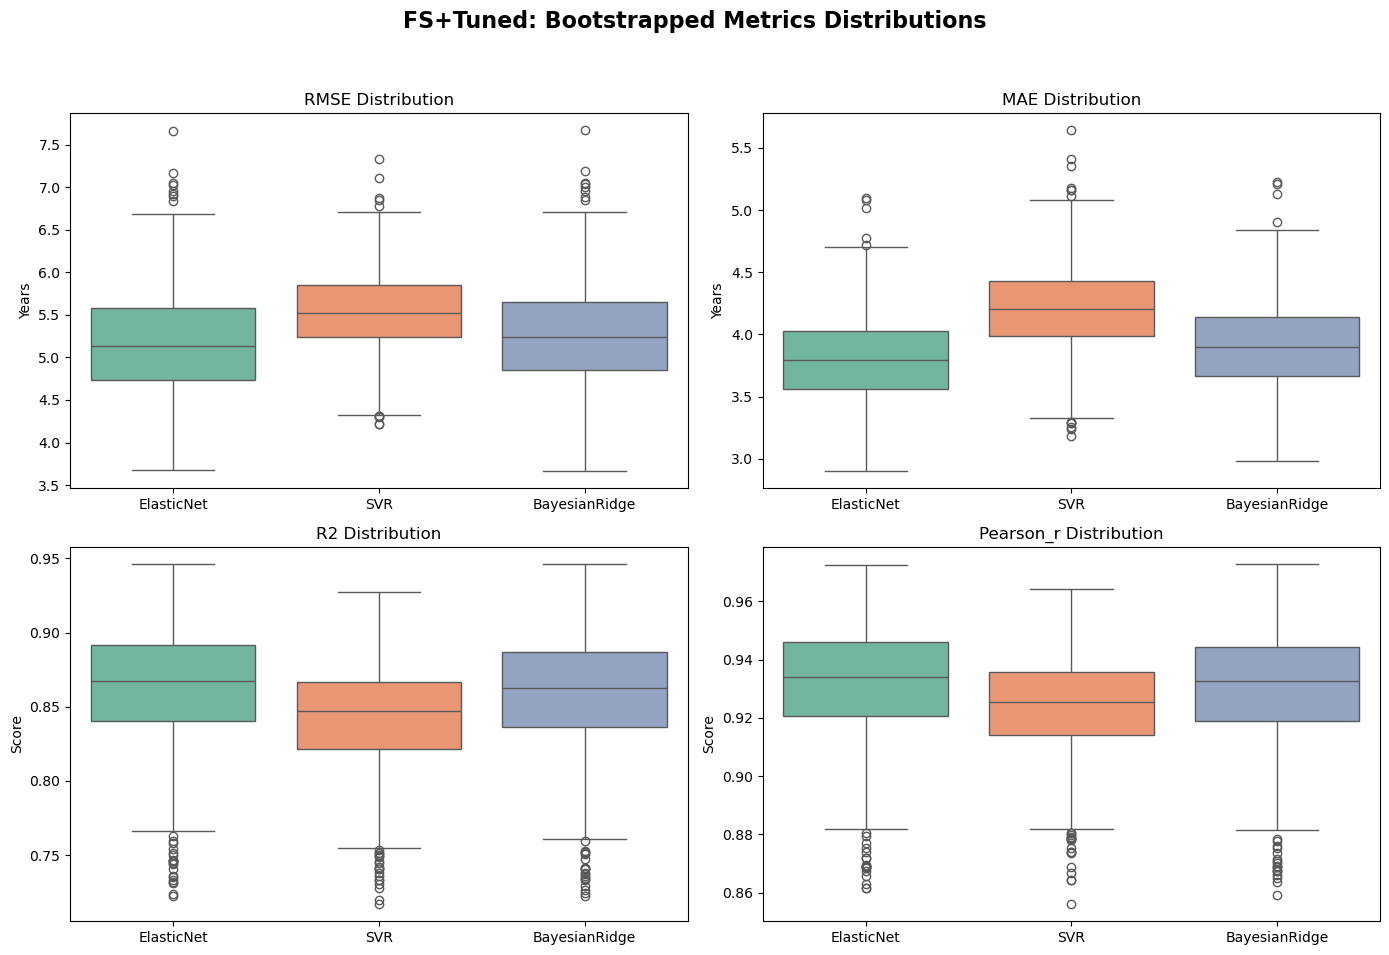

In [809]:
# bootstrap boxplots for all metrics

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('FS+Tuned: Bootstrapped Metrics Distributions', fontsize=16, fontweight='bold')

metric_indices = {
    'RMSE': 0, 
    'MAE': 1, 
    'R2': 2, 
    'Pearson_r': 3
}

for ax, (metric_name, col_idx) in zip(axes.flatten(), metric_indices.items()):
    
    plot_data = pd.DataFrame({
        model_name: model_array.iloc[:, col_idx] 
        for model_name, model_array in raw_metrics.items()
    })

    
    sns.boxplot(data=plot_data, ax=ax, palette="Set2")
    
    ax.set_title(f'{metric_name} Distribution')
    
    if metric_name in ['RMSE', 'MAE']:
        ax.set_ylabel('Years')
    else:
        ax.set_ylabel('Score')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f'{project_root}/figures/final_boxplots_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.3  Model selection and final model 

In [789]:
winner = best_models['ElasticNet']
joblib.dump(winner, f'{project_root}/models/best_model.pkl')

['C:\\Users\\User\\Desktop\\assignment_1/models/best_model.pkl']

# Bonus B: Sex Prediction from DNA Methylation 

## Preprocessing

In [137]:
from sklearn.model_selection import train_test_split

In [171]:
data_dir = project_root/'data'
sex_dev_df = pd.read_csv(f'{data_dir}/development_data.csv')
test_sex = pd.read_csv(f'{data_dir}/evaluation_data.csv')

train_sex, val_sex = train_test_split(sex_dev_df, test_size=0.8, random_state=seed)

In [201]:
from scipy.stats import pointbiserialr
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

import matplotlib.pyplot as plt

In [157]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

cpg_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
]).set_output(transform="pandas")

def xyz_sex(df, pipe, is_train=False):
    '''
    Features (X) & Targets (y) generation
    - Features (X): imputed & scaled 
    -  Targets (y): sex binary encoded 
    '''
    y = pd.get_dummies(df[['sex']], drop_first=True)
    y = y.rename(columns={'sex_M': 'sex'})
    
    X = df.drop(columns=['sample_id', 'age', 'ethnicity', 'sex'])

    X = pipe.fit_transform(X) if is_train else pipe.transform(X)
        
    return X, y

In [173]:
X_train_sex, y_train_sex =  xyz_sex(train_sex, cpg_pipe, is_train=True)
X_val_sex, y_val_sex = xyz_sex(val_sex, cpg_pipe)
X_test_sex, y_test_sex = xyz_sex(test_sex, cpg_pipe)

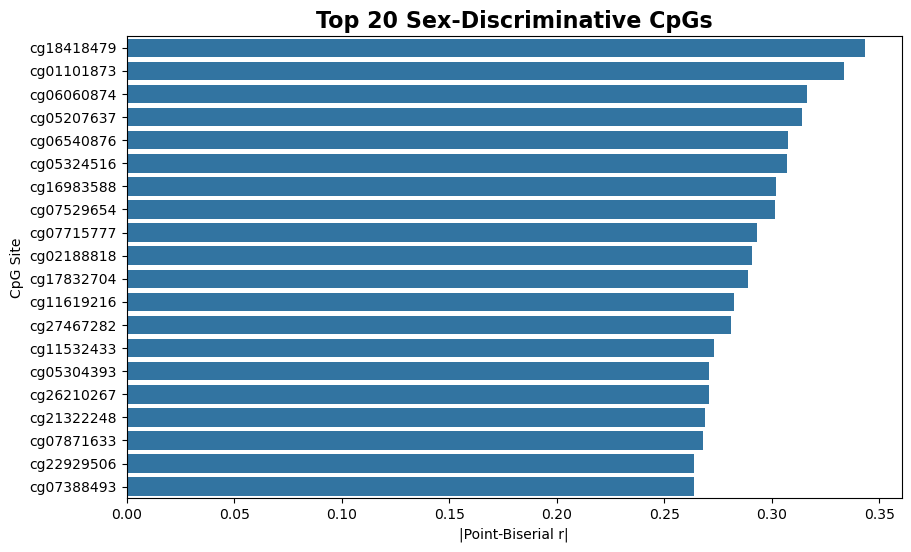

In [308]:
# |point-biserial r| corrs
pb_corrs = []
for col in X_train_sex.columns:
    corr, _ = pointbiserialr(np.ravel(y_train_sex), X_train_sex[col])
    pb_corrs.append((col, abs(corr)))

pb_corrs.sort(key=lambda x: x[1], reverse=True)
top20_sex_cpgs = pb_corrs[:20]

# Barplot Top 20
plt.figure(figsize=(10, 6))
sns.barplot(x=[x[1] for x in top20_sex_cpgs], y=[x[0] for x in top20_sex_cpgs])
plt.title("Top 20 Sex-Discriminative CpGs", fontsize=16, fontweight='bold')
plt.xlabel("|Point-Biserial r|")
plt.ylabel("CpG Site")

plt.savefig(f'{project_root}/figures/B_top20_sex.png', dpi=300, bbox_inches='tight')
plt.show()

In [236]:
# mRMR
mrmr_rank_sex = mrmr_regression(X=X_train_sex, y=y_train_sex, K=200, return_scores=False, show_progress=False)

LogRes = LogisticRegression(max_iter=1000)

ks = list(range(10, 201, 5))
accuracies = []

for k in ks:
    feats = mrmr_rank[:k]
    LogRes.fit(X_train_sex[feats], y_train_sex)
    
    y_hat_sex = LogRes.predict(X_val_sex[feats])
    
    accuracies.append(accuracy_score(y_val_sex, y_hat_sex))



Optimal K: 10


In [240]:
optimal_k_sex = ks[np.argmin(accuracies)]
mrmr_sex_feats = mrmr_rank_sex[:optimal_k_sex]

print(f"Optimal K: {optimal_k_sex}")

Optimal K: 10


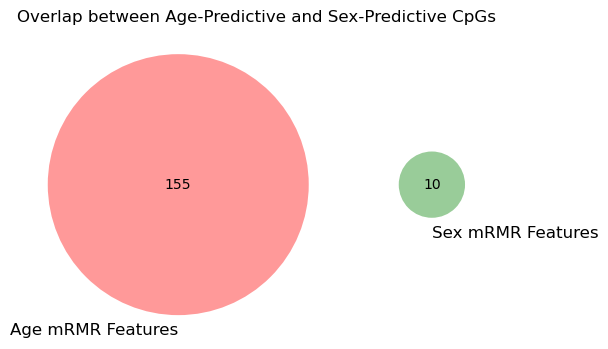

In [306]:
# venn overlap (Age vs Sex)
plt.figure(figsize=(6,6))
venn2([set(mrmr_feats), set(mrmr_sex_feats)], 
      set_labels=('Age mRMR Features', 'Sex mRMR Features'))
plt.title("Overlap between Age-Predictive and Sex-Predictive CpGs")
plt.savefig(f'{project_root}/figures/B_venn.png', dpi=300, bbox_inches='tight')
plt.show()

In [266]:
def bootstrap_classification(model, X_test, y_test, n_resamples=1000):
    metrics = {'Accuracy': [], 'F1': [], 'MCC': [], 'ROC-AUC': [], 'PR-AUC': []}
    n_samples = len(y_test)
    
    # Predict probabilities and classes once for the base model
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1] 
    
    for _ in range(n_resamples):
        indices = np.random.randint(0, n_samples, n_samples)
        y_boot = y_test.iloc[indices] if isinstance(y_test, pd.Series) else y_test[indices]
        preds_boot = preds[indices]
        probs_boot = probs[indices]
        
        # Calculate metrics (wrap in try-except in case a bootstrap sample only has 1 class)
        try:
            metrics['Accuracy'].append(accuracy_score(y_boot, preds_boot))
            metrics['F1'].append(f1_score(y_boot, preds_boot))
            metrics['MCC'].append(matthews_corrcoef(y_boot, preds_boot))
            metrics['ROC-AUC'].append(roc_auc_score(y_boot, probs_boot))
            metrics['PR-AUC'].append(average_precision_score(y_boot, probs_boot))
        except ValueError:
            continue

    # Calculate means and 95% CIs
    results = {}
    for k, v in metrics.items():
        results[k] = f"{np.mean(v):.3f} ± {np.std(v):.3f}, [{np.percentile(v, 2.5):.3f}-{np.percentile(v, 97.5):.3f}]"
    return results, metrics

In [270]:
X_dev_sex = pd.concat([X_train_sex[mrmr_sex_feats], X_val_sex[mrmr_sex_feats]], axis=0)
y_dev_sex = np.ravel(pd.concat([y_train_sex, y_val_sex], axis=0))

X_test_sex = X_test_sex[mrmr_sex_feats]
y_test_sex = np.ravel(y_test_sex)

In [274]:
# Train Models
LogRes = LogisticRegression(max_iter=1000)
LogRes.fit(X_dev_sex, y_dev_sex)

GNB = GaussianNB()
GNB.fit(X_dev_sex, y_dev_sex)

LogRes_results, LogRes_metrics = bootstrap_classification(LogRes, X_test_sex, y_test_sex)
GNB_results, GNB_metrics = bootstrap_classification(GNB, X_test_sex, y_test_sex)

print("Logistic Regression:", LogRes_results)
print("Gaussian NB:", GNB_results)

Logistic Regression: {'Accuracy': '0.798 ± 0.040, [0.710-0.870]', 'F1': '0.765 ± 0.051, [0.659-0.857]', 'MCC': '0.589 ± 0.082, [0.423-0.741]', 'ROC-AUC': '0.881 ± 0.034, [0.804-0.940]', 'PR-AUC': '0.869 ± 0.042, [0.773-0.937]'}
Gaussian NB: {'Accuracy': '0.733 ± 0.045, [0.640-0.820]', 'F1': '0.683 ± 0.060, [0.560-0.795]', 'MCC': '0.454 ± 0.092, [0.273-0.638]', 'ROC-AUC': '0.789 ± 0.046, [0.695-0.876]', 'PR-AUC': '0.740 ± 0.070, [0.594-0.859]'}


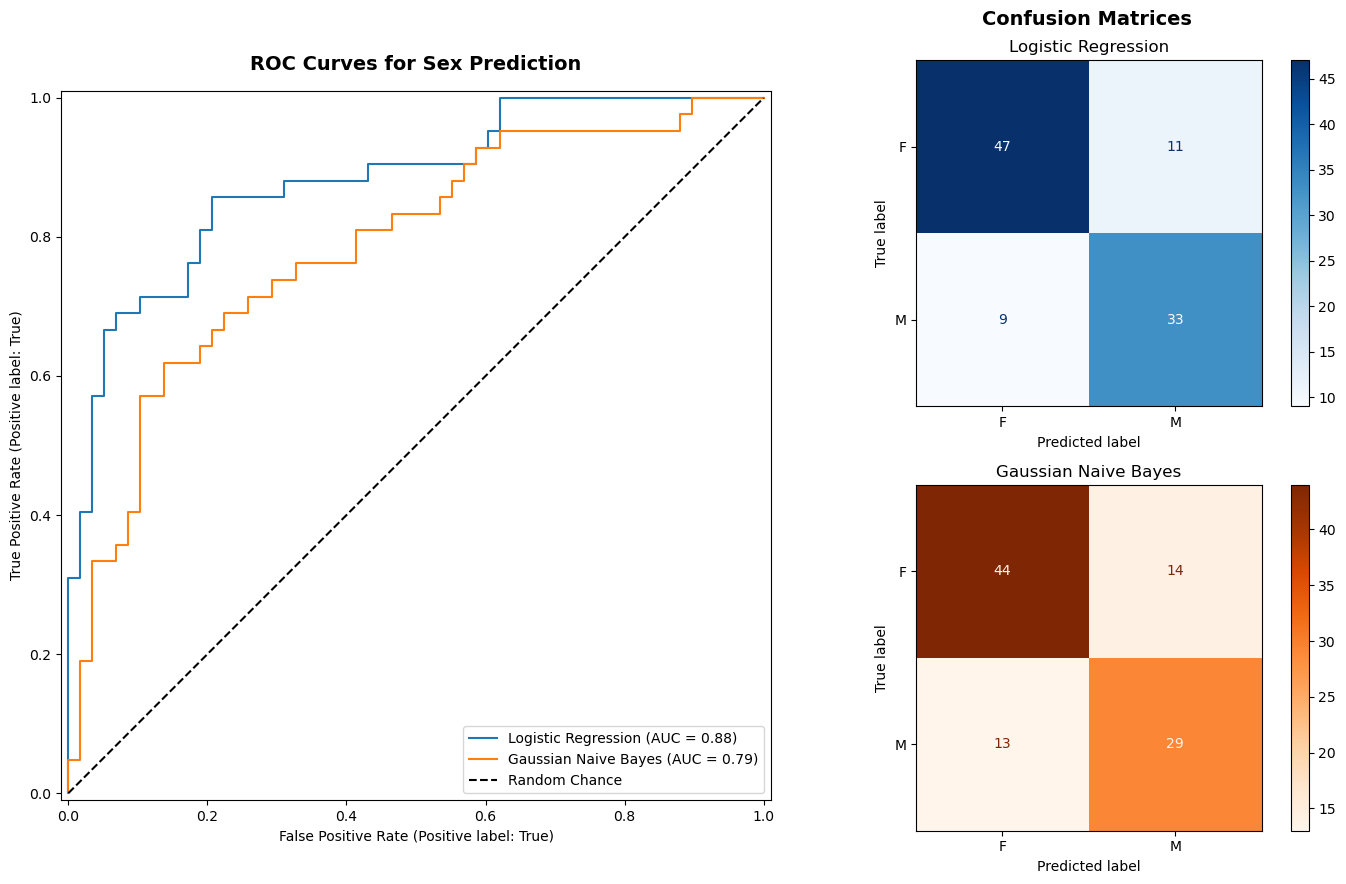

In [310]:
# ROC & ConfMatrices
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1]) 


ax_roc = fig.add_subplot(gs[:, 0])
ax_cm_lr = fig.add_subplot(gs[0, 1])
ax_cm_gnb = fig.add_subplot(gs[1, 1])

# ROC (Left)
RocCurveDisplay.from_estimator(LogRes, X_test_sex, y_test_sex, ax=ax_roc, name='Logistic Regression')
RocCurveDisplay.from_estimator(GNB, X_test_sex, y_test_sex, ax=ax_roc, name='Gaussian Naive Bayes')
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='k', label='Random Chance')
ax_roc.set_title("ROC Curves for Sex Prediction", fontsize=14, fontweight='bold', pad=15)
ax_roc.legend(loc='lower right')

# Confusion Matrices (Right)
ConfusionMatrixDisplay.from_estimator(LogRes, X_test_sex, y_test_sex, ax=ax_cm_lr, cmap='Blues', display_labels=['F', 'M'])
ax_cm_lr.set_title('Logistic Regression', fontsize=12)

ConfusionMatrixDisplay.from_estimator(GNB, X_test_sex, y_test_sex, ax=ax_cm_gnb, cmap='Oranges', display_labels=['F', 'M'])
ax_cm_gnb.set_title('Gaussian Naive Bayes', fontsize=12)

fig.text(0.78, 0.96, 'Confusion Matrices', fontsize=14, fontweight='bold', ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{project_root}/figures/B_ROC_conf.png', dpi=300, bbox_inches='tight')
plt.show()

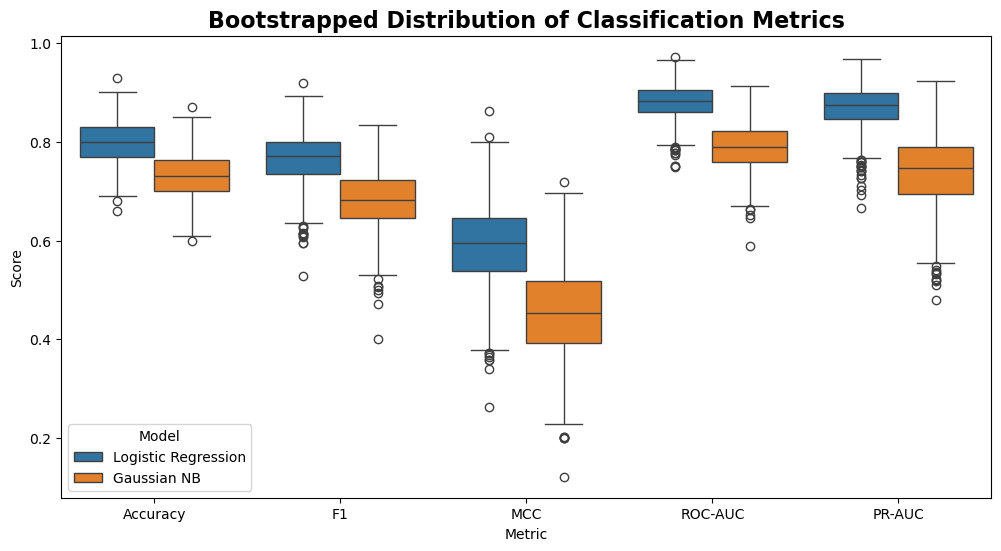

In [314]:
# boxplots

lr_df = pd.DataFrame(LogRes_metrics)
lr_df['Model'] = 'Logistic Regression'

gnb_df = pd.DataFrame(GNB_metrics)
gnb_df['Model'] = 'Gaussian NB'

plot_df = pd.concat([lr_df, gnb_df]).melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x='Metric', y='Score', hue='Model')
plt.title("Bootstrapped Distribution of Classification Metrics", fontsize=16, fontweight='bold')
plt.savefig(f'{project_root}/figures/B_boxplots.png', dpi=300, bbox_inches='tight')

plt.show()